# 12 — Rotate BCHH seismograms and compute polarization time series

This notebook extends the canonical Notebook 02 products. It:

1. loads the corrected three-component BCHH seismogram and event-epoch StationXML recorded in `02_analysis_configuration.json`;
2. verifies/rotates the seismic components to Z/N/E using ObsPy metadata;
3. rotates N/E to radial/transverse using the SLC-40 back-azimuth recorded by Notebook 02;
4. computes sliding-window covariance linearity, rectilinearity, and planarity;
5. computes complex-signal ellipticity, major/minor ellipse orientation, and degree of polarization with TwistPy;
6. writes reusable CSV, NPZ, Pickle, JSON, and diagnostic-figure products for Notebook 13;
7. creates TwistPy-style polarization figures in both geographic Z/N/E and source-relative Z/R/T coordinates.

TwistPy is run on geographic Z/N/E components, as required for meaningful geographic azimuths. The Z/R/T figure uses the same polarization solution but converts the ellipse azimuths to source-relative angles with respect to the SLC-40 back-azimuth.


## 1. Imports, project paths, and authoritative inputs


In [1]:
from __future__ import annotations

import json
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import Stream, Trace, UTCDateTime, read, read_inventory
from obspy.signal.rotate import rotate_ne_rt

try:
    from twistpy.polarization import TimeDomainAnalysis3C
except ImportError as exc:
    raise ImportError(
        "TwistPy is required for Notebook 12. Install it in this kernel with "
        "`python -m pip install twistpy`."
    ) from exc

project_root = Path.cwd().resolve()
if project_root.name == "notebooks2":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

ANALYSIS_CONFIG_FILE = config.OUTPUT_DIR / "02_analysis_configuration.json"
if not ANALYSIS_CONFIG_FILE.exists():
    raise FileNotFoundError(
        f"Run 02_prepare_analysis_inputs.ipynb first: {ANALYSIS_CONFIG_FILE}"
    )

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())

SOURCE_STREAM_FILE = Path(
    analysis_config["baseline_removed_streams"]["pickle"]
).expanduser()
STATIONXML_FILE = Path(
    analysis_config["notebook_01_products"]["calibrated_stationxml"]
).expanduser()

for label, path in {
    "corrected waveform Stream": SOURCE_STREAM_FILE,
    "calibrated StationXML": STATIONXML_FILE,
}.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")

OUTPUT_ROOT = config.OUTPUT_DIR / "12_polarization"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
config.FIGURE_DIR.mkdir(parents=True, exist_ok=True)

POLARIZATION_CSV = OUTPUT_ROOT / "12_polarization_timeseries.csv"
POLARIZATION_NPZ = OUTPUT_ROOT / "12_polarization_timeseries.npz"
ROTATED_ZNE_PICKLE = OUTPUT_ROOT / "12_seismic_zne.pkl"
ROTATED_ZRT_PICKLE = OUTPUT_ROOT / "12_seismic_zrt.pkl"
SUMMARY_JSON = OUTPUT_ROOT / "12_polarization_summary.json"
DIAGNOSTIC_FIGURE = config.FIGURE_DIR / "12_polarization_diagnostics.png"
TWISTPY_ZNE_FIGURE = config.FIGURE_DIR / "12_twistpy_style_zne.png"
TWISTPY_ZRT_FIGURE = config.FIGURE_DIR / "12_twistpy_style_zrt.png"

print("Waveform source:", SOURCE_STREAM_FILE)
print("StationXML:", STATIONXML_FILE)
print("Output directory:", OUTPUT_ROOT)


Waveform source: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/derived2/bchh_corrected_moving_median_baseline_removed.pkl
StationXML: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/01_BCHH_20160901_empirically_calibrated.xml
Output directory: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization


## 2. Analysis controls


In [2]:
# Filtering used for both covariance and TwistPy analysis.
FILTER_FREQMIN_HZ = 0.5
FILTER_FREQMAX_HZ = 20.0
FILTER_CORNERS = 4
FILTER_ZEROPHASE = True

# TwistPy and covariance window controls.
WINDOW_LENGTH_S = 0.50
WINDOW_OVERLAP = 0.90

# Figure interval. These values can be changed to inspect an individual pulse.
# The default covers the principal explosion and subsequent arrivals.
PLOT_START = config.EXPLOSION_TIME - 2.0
PLOT_END = config.EXPLOSION_TIME + 18.0

# Display controls for the TwistPy-style plots.
NORMALIZE_COMPONENTS = True
WAVEFORM_LINEWIDTH = 0.9
POLARIZATION_MARKER_SIZE = 9
SHOW_LOW_DOP = True
DOP_DISPLAY_THRESHOLD = 0.0   # e.g. 0.6 to suppress poorly polarized windows

# Leave None to analyze the complete canonical Notebook 02 time window.
ANALYSIS_START = None
ANALYSIS_END = None

if not (0.0 <= WINDOW_OVERLAP < 1.0):
    raise ValueError("WINDOW_OVERLAP must be in [0, 1).")
if PLOT_END <= PLOT_START:
    raise ValueError("PLOT_END must be later than PLOT_START.")
if not (0.0 <= DOP_DISPLAY_THRESHOLD <= 1.0):
    raise ValueError("DOP_DISPLAY_THRESHOLD must be in [0, 1].")


## 3. Load, isolate, and rotate the three-component seismogram


In [3]:
st_all = read(str(SOURCE_STREAM_FILE), format="PICKLE")
inventory = read_inventory(str(STATIONXML_FILE))


def utc_epoch_seconds(value) -> float:
    """Return epoch seconds for ObsPy UTCDateTime or datetime-like values."""
    if isinstance(value, UTCDateTime):
        return float(value.timestamp)
    timestamp = getattr(value, "timestamp", None)
    if callable(timestamp):
        return float(timestamp())
    if timestamp is not None:
        return float(timestamp)
    return float(UTCDateTime(value).timestamp)


def unique_component(stream: Stream, component: str) -> Trace:
    """Return exactly one trace whose channel code ends with component."""
    component = component.upper()
    matches = [
        trace for trace in stream
        if str(trace.stats.channel).upper().endswith(component)
    ]
    if len(matches) != 1:
        raise ValueError(
            f"Expected one {component} component; "
            f"found {[trace.id for trace in matches]}"
        )
    return matches[0]


def assert_sample_aligned(
    traces: tuple[Trace, ...],
    *,
    labels: tuple[str, ...] = ("Z", "N", "E"),
) -> None:
    """Validate that traces share one sampling grid without hashing UTCDateTime."""
    if len(traces) != len(labels):
        raise ValueError("traces and labels must have the same length")

    sampling_rates = np.asarray(
        [float(trace.stats.sampling_rate) for trace in traces],
        dtype=float,
    )
    npts = np.asarray([int(trace.stats.npts) for trace in traces], dtype=int)
    starttimes = [trace.stats.starttime for trace in traces]
    endtimes = [trace.stats.endtime for trace in traces]

    reference_start = starttimes[0]
    start_offsets_s = np.asarray(
        [float(starttime - reference_start) for starttime in starttimes],
        dtype=float,
    )

    reference_end = endtimes[0]
    end_offsets_s = np.asarray(
        [float(endtime - reference_end) for endtime in endtimes],
        dtype=float,
    )

    sampling_rate_ok = np.allclose(
        sampling_rates,
        sampling_rates[0],
        rtol=0.0,
        atol=1e-9,
    )
    npts_ok = bool(np.all(npts == npts[0]))

    # UTCDateTime subtraction is robust here and avoids placing UTCDateTime
    # objects in sets, which fails with some ObsPy versions.
    time_tolerance_s = max(1e-9, 1e-6 / sampling_rates[0])
    starts_ok = np.allclose(
        start_offsets_s,
        0.0,
        rtol=0.0,
        atol=time_tolerance_s,
    )
    ends_ok = np.allclose(
        end_offsets_s,
        0.0,
        rtol=0.0,
        atol=time_tolerance_s,
    )

    if not (sampling_rate_ok and npts_ok and starts_ok and ends_ok):
        details = "\n".join(
            f"  {label}: id={trace.id}, sr={trace.stats.sampling_rate}, "
            f"npts={trace.stats.npts}, start={trace.stats.starttime}, "
            f"end={trace.stats.endtime}, "
            f"start_offset_s={start_offset:.12g}, "
            f"end_offset_s={end_offset:.12g}"
            for label, trace, start_offset, end_offset in zip(
                labels, traces, start_offsets_s, end_offsets_s
            )
        )
        raise ValueError(
            "Z/N/E traces are not sample-aligned after common-window trimming.\n"
            f"{details}"
        )


seismic_channels = tuple(
    str(channel).upper() for channel in analysis_config["seismic_channels"]
)
st_seismic = Stream([
    trace.copy()
    for trace in st_all
    if str(trace.stats.channel).upper() in seismic_channels
])

if len(st_seismic) != 3:
    raise ValueError(
        "Expected exactly three canonical seismic components from Notebook 02; "
        f"requested channels={list(seismic_channels)}, "
        f"found={[trace.id for trace in st_seismic]}"
    )

if ANALYSIS_START is not None or ANALYSIS_END is not None:
    requested_start = (
        UTCDateTime(ANALYSIS_START)
        if ANALYSIS_START is not None
        else min(trace.stats.starttime for trace in st_seismic)
    )
    requested_end = (
        UTCDateTime(ANALYSIS_END)
        if ANALYSIS_END is not None
        else max(trace.stats.endtime for trace in st_seismic)
    )
    if requested_end <= requested_start:
        raise ValueError(
            f"ANALYSIS_END must be after ANALYSIS_START: "
            f"{requested_start} to {requested_end}"
        )
    st_seismic.trim(requested_start, requested_end, pad=False)

# First use the channels exactly as stored when they are already Z/N/E.
# Otherwise rotate the three recorded sensor axes to geographic Z/N/E using
# the event-epoch StationXML orientation metadata produced by Notebook 01.
components_before_rotation = {
    str(trace.stats.channel)[-1].upper() for trace in st_seismic
}
if components_before_rotation == {"Z", "N", "E"}:
    st_zne = st_seismic.copy()
    rotation_method = "input channels already Z/N/E"
else:
    st_zne = st_seismic.copy()
    try:
        st_zne.rotate(method="->ZNE", inventory=inventory)
    except Exception as exc:
        raise RuntimeError(
            "ObsPy could not rotate the canonical seismic channels to Z/N/E. "
            f"Input traces were {[trace.id for trace in st_seismic]}. "
            "Check that the event-epoch StationXML contains azimuth and dip "
            "for all three channels."
        ) from exc
    rotation_method = "ObsPy ->ZNE using calibrated StationXML"

# Merge segments component-by-component, then retain only the common time
# interval. Interpolation is used only to fill internal gaps during merging;
# no padding is added beyond the observed common interval.
st_zne.merge(method=1, fill_value="interpolate")
if len(st_zne) != 3:
    raise ValueError(
        "Expected exactly three traces after Z/N/E rotation and merging; "
        f"found {[trace.id for trace in st_zne]}"
    )

common_start = max(trace.stats.starttime for trace in st_zne)
common_end = min(trace.stats.endtime for trace in st_zne)
if common_end <= common_start:
    raise ValueError(
        "The rotated Z/N/E components have no common time interval: "
        f"common_start={common_start}, common_end={common_end}"
    )

st_zne.trim(common_start, common_end, pad=False, nearest_sample=True)
st_zne.sort(keys=["channel"])

tr_z = unique_component(st_zne, "Z")
tr_n = unique_component(st_zne, "N")
tr_e = unique_component(st_zne, "E")
assert_sample_aligned((tr_z, tr_n, tr_e))

back_azimuth_deg = float(
    analysis_config["array_reference"]["back_azimuth_to_slc40_deg"]
)
if not np.isfinite(back_azimuth_deg):
    raise ValueError(
        "Notebook 02 supplied a non-finite SLC-40 back-azimuth: "
        f"{back_azimuth_deg}"
    )

r_data, t_data = rotate_ne_rt(
    np.asarray(tr_n.data, dtype=np.float64),
    np.asarray(tr_e.data, dtype=np.float64),
    back_azimuth_deg,
)

tr_r = tr_n.copy()
tr_r.data = np.asarray(r_data, dtype=np.float64)
tr_r.stats.channel = str(tr_r.stats.channel)[:-1] + "R"
tr_r.stats.processing = list(getattr(tr_r.stats, "processing", []))
tr_r.stats.processing.append(
    f"ObsPy NE->RT rotation; back_azimuth={back_azimuth_deg:.6f} deg"
)

tr_t = tr_e.copy()
tr_t.data = np.asarray(t_data, dtype=np.float64)
tr_t.stats.channel = str(tr_t.stats.channel)[:-1] + "T"
tr_t.stats.processing = list(getattr(tr_t.stats, "processing", []))
tr_t.stats.processing.append(
    f"ObsPy NE->RT rotation; back_azimuth={back_azimuth_deg:.6f} deg"
)

st_zrt = Stream([tr_z.copy(), tr_r, tr_t])
assert_sample_aligned(tuple(st_zrt), labels=("Z", "R", "T"))

# Use ObsPy's PICKLE writer so these products can be read consistently with
# read(..., format="PICKLE") in Notebook 13.
st_zne.write(str(ROTATED_ZNE_PICKLE), format="PICKLE")
st_zrt.write(str(ROTATED_ZRT_PICKLE), format="PICKLE")

print("Input seismic channels:", [trace.id for trace in st_seismic])
print("Rotation to ZNE:", rotation_method)
print("ZNE:", [trace.id for trace in st_zne])
print("ZRT:", [trace.id for trace in st_zrt])
print(
    "Common interval:",
    tr_z.stats.starttime,
    "to",
    tr_z.stats.endtime,
    f"({tr_z.stats.npts} samples at {tr_z.stats.sampling_rate:g} Hz)",
)
print(f"SLC-40 back-azimuth: {back_azimuth_deg:.3f}°")


Input seismic channels: ['1R.BCHH.10.DHE', '1R.BCHH.10.DHN', '1R.BCHH.10.DHZ']
Rotation to ZNE: input channels already Z/N/E
ZNE: ['1R.BCHH.10.DHE', '1R.BCHH.10.DHN', '1R.BCHH.10.DHZ']
ZRT: ['1R.BCHH.10.DHZ', '1R.BCHH.10.DHR', '1R.BCHH.10.DHT']
Common interval: 2016-09-01T13:04:12.080000Z to 2016-09-01T13:37:12.080000Z (495001 samples at 250 Hz)
SLC-40 back-azimuth: 199.438°


## 4. Prepare the filtered analysis traces


In [4]:
def prepare_analysis_stream(stream: Stream) -> Stream:
    """Return a consistently detrended, tapered, and filtered copy."""
    out = stream.copy()
    out.detrend("linear")
    out.detrend("demean")
    out.taper(max_percentage=0.02, type="cosine")
    out.filter(
        "bandpass",
        freqmin=FILTER_FREQMIN_HZ,
        freqmax=FILTER_FREQMAX_HZ,
        corners=FILTER_CORNERS,
        zerophase=FILTER_ZEROPHASE,
    )
    return out


# TwistPy uses geographic N/E/Z. The rotated stream is retained separately for
# source-relative waveform display and radial/transverse measurements.
st_analysis_zne = prepare_analysis_stream(st_zne)
st_analysis_zrt = prepare_analysis_stream(st_zrt)

z = unique_component(st_analysis_zne, "Z")
n = unique_component(st_analysis_zne, "N")
e = unique_component(st_analysis_zne, "E")

z_rt = unique_component(st_analysis_zrt, "Z")
r = unique_component(st_analysis_zrt, "R")
t = unique_component(st_analysis_zrt, "T")

assert_sample_aligned((z, n, e), labels=("Z", "N", "E"))
assert_sample_aligned((z_rt, r, t), labels=("Z", "R", "T"))

print("Filtered ZNE stream:")
print(st_analysis_zne)
print("\nFiltered ZRT stream:")
print(st_analysis_zrt)


Filtered ZNE stream:
3 Trace(s) in Stream:
1R.BCHH.10.DHE | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHN | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples

Filtered ZRT stream:
3 Trace(s) in Stream:
1R.BCHH.10.DHZ | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHR | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples
1R.BCHH.10.DHT | 2016-09-01T13:04:12.080000Z - 2016-09-01T13:37:12.080000Z | 250.0 Hz, 495001 samples


## 5. Covariance linearity, rectilinearity, and planarity


In [5]:
def covariance_polarization(
    z_values: np.ndarray,
    n_values: np.ndarray,
    e_values: np.ndarray,
    *,
    sampling_rate_hz: float,
    window_length_s: float,
    overlap: float,
):
    """Sliding real-covariance polarization in [Z, N, E] coordinates."""
    x = np.column_stack([
        np.asarray(z_values, dtype=float),
        np.asarray(n_values, dtype=float),
        np.asarray(e_values, dtype=float),
    ])
    nwin = max(3, int(round(window_length_s * sampling_rate_hz)))
    nstep = max(1, int(round(nwin * (1.0 - overlap))))

    rows = []
    for i0 in range(0, len(x) - nwin + 1, nstep):
        xx = x[i0:i0 + nwin]
        finite = np.isfinite(xx).all(axis=1)
        xx = xx[finite]
        center_sample = i0 + 0.5 * (nwin - 1)

        if len(xx) < 3:
            rows.append((center_sample, *([np.nan] * 8)))
            continue

        xx = xx - xx.mean(axis=0, keepdims=True)
        covariance = np.cov(xx, rowvar=False, bias=False)
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues = np.maximum(eigenvalues[order], 0.0)
        eigenvectors = eigenvectors[:, order]
        lambda1, lambda2, lambda3 = eigenvalues

        # The waveform units are velocity, so valid covariance eigenvalues can
        # be far below machine epsilon in absolute magnitude (e.g. 1e-24).
        # Machine epsilon is a relative precision measure, not a physical
        # amplitude threshold. Only reject non-finite or genuinely zero energy.
        if not np.isfinite(lambda1) or lambda1 <= np.finfo(float).tiny:
            linearity = rectilinearity = planarity = np.nan
            azimuth_deg = incidence_deg = np.nan
        else:
            linearity = (lambda1 - lambda2) / lambda1
            rectilinearity = 1.0 - (lambda2 + lambda3) / (2.0 * lambda1)
            planarity = (lambda2 - lambda3) / lambda1

            vz, vn, ve = eigenvectors[:, 0]
            if vz < 0:
                vz, vn, ve = -vz, -vn, -ve
            incidence_deg = np.degrees(np.arctan2(np.hypot(vn, ve), abs(vz)))
            azimuth_deg = np.degrees(np.arctan2(ve, vn)) % 180.0

        rows.append((
            center_sample,
            linearity,
            rectilinearity,
            planarity,
            azimuth_deg,
            incidence_deg,
            lambda1,
            lambda2,
            lambda3,
        ))

    columns = [
        "center_sample", "linearity", "rectilinearity", "planarity",
        "covariance_azimuth_deg", "covariance_incidence_deg",
        "lambda1", "lambda2", "lambda3",
    ]
    return pd.DataFrame(rows, columns=columns), nwin, nstep


sampling_rate_hz = float(z.stats.sampling_rate)
covariance_df, covariance_nwin, covariance_nstep = covariance_polarization(
    z.data,
    n.data,
    e.data,
    sampling_rate_hz=sampling_rate_hz,
    window_length_s=WINDOW_LENGTH_S,
    overlap=WINDOW_OVERLAP,
)

covariance_df["time_epoch_s"] = (
    utc_epoch_seconds(z.stats.starttime)
    + covariance_df["center_sample"] / sampling_rate_hz
)
covariance_df["time_utc"] = covariance_df["time_epoch_s"].map(
    lambda value: str(UTCDateTime(value))
)
covariance_df["elapsed_from_explosion_s"] = (
    covariance_df["time_epoch_s"] - utc_epoch_seconds(config.EXPLOSION_TIME)
)

display(covariance_df.head())


,center_sample,linearity,rectilinearity,planarity,covariance_azimuth_deg,covariance_incidence_deg,lambda1,lambda2,lambda3,time_epoch_s,time_utc,elapsed_from_explosion_s
0,62.0,0.994573,0.997178,0.005209,20.225884,73.045764,1.674393e-24,9.086617e-27,3.653293e-28,1.472735e+09,2016-09-01T13:04:12.328000Z,-179.752
1,74.0,0.995976,0.997835,0.003718,17.954378,74.428655,2.052267e-24,8.259153e-27,6.278682e-28,1.472735e+09,2016-09-01T13:04:12.376000Z,-179.704
2,86.0,0.997236,0.998205,0.001938,15.747447,74.512940,2.385822e-24,6.595558e-27,1.971390e-27,1.472735e+09,2016-09-01T13:04:12.424000Z,-179.656
3,98.0,0.997017,0.998103,0.002171,13.408950,75.511841,2.756212e-24,8.221588e-27,2.236518e-27,1.472735e+09,2016-09-01T13:04:12.472000Z,-179.608
4,110.0,0.996444,0.997706,0.002522,11.170975,76.176576,2.950495e-24,1.049092e-26,3.048833e-27,1.472735e+09,2016-09-01T13:04:12.520000Z,-179.560


## 6. TwistPy complex-signal ellipticity


In [6]:
analysis = TimeDomainAnalysis3C(
    N=n,
    E=e,
    Z=z,
    window={
        "window_length_seconds": float(WINDOW_LENGTH_S),
        "overlap": float(WINDOW_OVERLAP),
    },
    timeaxis="rel",
)
analysis.polarization_analysis()

# TwistPy's ``timeaxis="utc"`` returns Matplotlib serial-day values, not
# Unix epoch seconds. Using those values as epoch seconds places the results
# near 1970 and causes every event-window plot to be empty. Use the relative
# time axis and anchor it explicitly to the waveform start time.
twistpy_relative_s = np.asarray(analysis.t_windows, dtype=float)
twistpy_epoch_s = (
    utc_epoch_seconds(z.stats.starttime)
    + twistpy_relative_s
)

if len(twistpy_epoch_s) == 0:
    raise RuntimeError("TwistPy returned no polarization windows.")
if not np.all(np.isfinite(twistpy_epoch_s)):
    raise RuntimeError("TwistPy returned non-finite polarization times.")

major_azimuth_deg = np.asarray(analysis.azi1, dtype=float)
minor_azimuth_deg = np.asarray(analysis.azi2, dtype=float)

# Fold source-relative azimuth to [0, 180):
#   0/180 = radial plane; 90 = transverse direction.
major_source_relative_deg = (major_azimuth_deg - back_azimuth_deg) % 180.0
minor_source_relative_deg = (minor_azimuth_deg - back_azimuth_deg) % 180.0

twistpy_df = pd.DataFrame({
    "time_epoch_s": twistpy_epoch_s,
    "time_utc": [str(UTCDateTime(value)) for value in twistpy_epoch_s],
    "elapsed_from_explosion_s": twistpy_epoch_s - utc_epoch_seconds(config.EXPLOSION_TIME),
    "ellipticity": np.asarray(analysis.elli, dtype=float),
    "degree_of_polarization": np.asarray(analysis.dop, dtype=float),
    "twistpy_major_azimuth_deg": major_azimuth_deg,
    "twistpy_minor_azimuth_deg": minor_azimuth_deg,
    "twistpy_major_source_relative_azimuth_deg": major_source_relative_deg,
    "twistpy_minor_source_relative_azimuth_deg": minor_source_relative_deg,
    "twistpy_major_inclination_deg": np.asarray(analysis.inc1, dtype=float),
    "twistpy_minor_inclination_deg": np.asarray(analysis.inc2, dtype=float),
})

display(twistpy_df.head())
print("Covariance windows:", len(covariance_df))
print("TwistPy windows:", len(twistpy_df))
print(
    "TwistPy UTC range:",
    UTCDateTime(twistpy_epoch_s[0]),
    "to",
    UTCDateTime(twistpy_epoch_s[-1]),
)
print(
    "TwistPy elapsed range relative to explosion:",
    f"{twistpy_df['elapsed_from_explosion_s'].iloc[0]:.3f}",
    "to",
    f"{twistpy_df['elapsed_from_explosion_s'].iloc[-1]:.3f}",
    "s",
)


Computing covariance matrices...
Covariance matrices computed!
Computing polarization attributes...
Polarization attributes have been computed!
Computing polarization attributes...
Polarization attributes have been computed!


,time_epoch_s,time_utc,elapsed_from_explosion_s,ellipticity,degree_of_polarization,twistpy_major_azimuth_deg,twistpy_minor_azimuth_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_inclination_deg
0,1.472735e+09,2016-09-01T13:04:12.328000Z,-179.752,0.323972,0.952773,10.239073,103.960971,170.801047,84.522945,75.689424,75.722947
1,1.472735e+09,2016-09-01T13:04:12.376000Z,-179.704,0.336714,0.985003,11.674304,105.499654,172.236278,86.061628,75.569626,75.465050
2,1.472735e+09,2016-09-01T13:04:12.424000Z,-179.656,0.338458,0.992121,12.737491,106.678196,173.299465,87.240169,75.055035,75.561612
3,1.472735e+09,2016-09-01T13:04:12.472000Z,-179.608,0.332106,0.994628,13.481031,107.396875,174.043004,87.958849,75.054367,75.649430
4,1.472735e+09,2016-09-01T13:04:12.520000Z,-179.560,0.330487,0.995754,13.972426,108.034615,174.534400,88.596589,75.023442,75.168011


Covariance windows: 41240
TwistPy windows: 41240
TwistPy UTC range: 2016-09-01T13:04:12.328000Z to 2016-09-01T13:37:11.800000Z
TwistPy elapsed range relative to explosion: -179.752 to 1799.720 s


## 7. Merge and write the canonical polarization products


In [7]:
# The implementations can differ by a fraction of a sample in their window
# centers. Merge each covariance result onto the nearest TwistPy window with a
# tolerance of one covariance step.
merge_tolerance_s = max(
    covariance_nstep / sampling_rate_hz,
    1.0 / sampling_rate_hz,
)

polarization = pd.merge_asof(
    twistpy_df.sort_values("time_epoch_s"),
    covariance_df.drop(columns=["time_utc", "elapsed_from_explosion_s"]).sort_values("time_epoch_s"),
    on="time_epoch_s",
    direction="nearest",
    tolerance=merge_tolerance_s,
)

preferred_order = [
    "time_utc", "time_epoch_s", "elapsed_from_explosion_s",
    "linearity", "rectilinearity", "planarity", "ellipticity",
    "degree_of_polarization",
    "covariance_azimuth_deg", "covariance_incidence_deg",
    "twistpy_major_azimuth_deg", "twistpy_major_inclination_deg",
    "twistpy_minor_azimuth_deg", "twistpy_minor_inclination_deg",
    "twistpy_major_source_relative_azimuth_deg",
    "twistpy_minor_source_relative_azimuth_deg",
    "lambda1", "lambda2", "lambda3", "center_sample",
]
polarization = polarization[[
    column for column in preferred_order if column in polarization.columns
]]

polarization.to_csv(POLARIZATION_CSV, index=False)
np.savez_compressed(
    POLARIZATION_NPZ,
    **{
        column: polarization[column].to_numpy()
        for column in polarization.columns
        if column != "time_utc"
    },
)

summary = {
    "producer_notebook": "12_rotate_and_compute_polarization.ipynb",
    "source_analysis_configuration": str(ANALYSIS_CONFIG_FILE),
    "source_waveform_stream": str(SOURCE_STREAM_FILE),
    "stationxml": str(STATIONXML_FILE),
    "seismic_channels": list(seismic_channels),
    "back_azimuth_to_slc40_deg": back_azimuth_deg,
    "zne_rotation_method": rotation_method,
    "common_start_utc": str(tr_z.stats.starttime),
    "common_end_utc": str(tr_z.stats.endtime),
    "sampling_rate_hz": float(tr_z.stats.sampling_rate),
    "npts": int(tr_z.stats.npts),
    "filter": {
        "type": "bandpass",
        "freqmin_hz": FILTER_FREQMIN_HZ,
        "freqmax_hz": FILTER_FREQMAX_HZ,
        "corners": FILTER_CORNERS,
        "zerophase": FILTER_ZEROPHASE,
    },
    "window_length_s": WINDOW_LENGTH_S,
    "window_overlap": WINDOW_OVERLAP,
    "covariance_step_s": covariance_nstep / sampling_rate_hz,
    "definitions": {
        "linearity": "(lambda1 - lambda2) / lambda1",
        "rectilinearity": "1 - (lambda2 + lambda3) / (2 lambda1)",
        "planarity": "(lambda2 - lambda3) / lambda1",
        "ellipticity": "TwistPy complex-signal polarization ellipse attribute",
        "source_relative_azimuth": "(geographic ellipse azimuth - SLC-40 back-azimuth) modulo 180 deg",
    },
    "outputs": {
        "polarization_csv": str(POLARIZATION_CSV),
        "polarization_npz": str(POLARIZATION_NPZ),
        "rotated_zne_pickle": str(ROTATED_ZNE_PICKLE),
        "rotated_zrt_pickle": str(ROTATED_ZRT_PICKLE),
        "diagnostic_figure": str(DIAGNOSTIC_FIGURE),
    },
}
SUMMARY_JSON.write_text(json.dumps(summary, indent=2) + "\n")

for path in (POLARIZATION_CSV, POLARIZATION_NPZ, ROTATED_ZNE_PICKLE, ROTATED_ZRT_PICKLE, SUMMARY_JSON):
    if not path.exists():
        raise FileNotFoundError(path)
    print(path)

display(polarization.head())


/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.csv
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.npz
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zne.pkl
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zrt.pkl
/Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_summary.json


,time_utc,time_epoch_s,elapsed_from_explosion_s,linearity,rectilinearity,planarity,ellipticity,degree_of_polarization,covariance_azimuth_deg,covariance_incidence_deg,twistpy_major_azimuth_deg,twistpy_major_inclination_deg,twistpy_minor_azimuth_deg,twistpy_minor_inclination_deg,twistpy_major_source_relative_azimuth_deg,twistpy_minor_source_relative_azimuth_deg,lambda1,lambda2,lambda3,center_sample
0,2016-09-01T13:04:12.328000Z,1.472735e+09,-179.752,0.994573,0.997178,0.005209,0.323972,0.952773,20.225884,73.045764,10.239073,75.689424,103.960971,75.722947,170.801047,84.522945,1.674393e-24,9.086617e-27,3.653293e-28,62.0
1,2016-09-01T13:04:12.376000Z,1.472735e+09,-179.704,0.995976,0.997835,0.003718,0.336714,0.985003,17.954378,74.428655,11.674304,75.569626,105.499654,75.465050,172.236278,86.061628,2.052267e-24,8.259153e-27,6.278682e-28,74.0
2,2016-09-01T13:04:12.424000Z,1.472735e+09,-179.656,0.997236,0.998205,0.001938,0.338458,0.992121,15.747447,74.512940,12.737491,75.055035,106.678196,75.561612,173.299465,87.240169,2.385822e-24,6.595558e-27,1.971390e-27,86.0
3,2016-09-01T13:04:12.472000Z,1.472735e+09,-179.608,0.997017,0.998103,0.002171,0.332106,0.994628,13.408950,75.511841,13.481031,75.054367,107.396875,75.649430,174.043004,87.958849,2.756212e-24,8.221588e-27,2.236518e-27,98.0
4,2016-09-01T13:04:12.520000Z,1.472735e+09,-179.560,0.996444,0.997706,0.002522,0.330487,0.995754,11.170975,76.176576,13.972426,75.023442,108.034615,75.168011,174.534400,88.596589,2.950495e-24,1.049092e-26,3.048833e-27,110.0


## 8. Diagnostic and TwistPy-style polarization figures


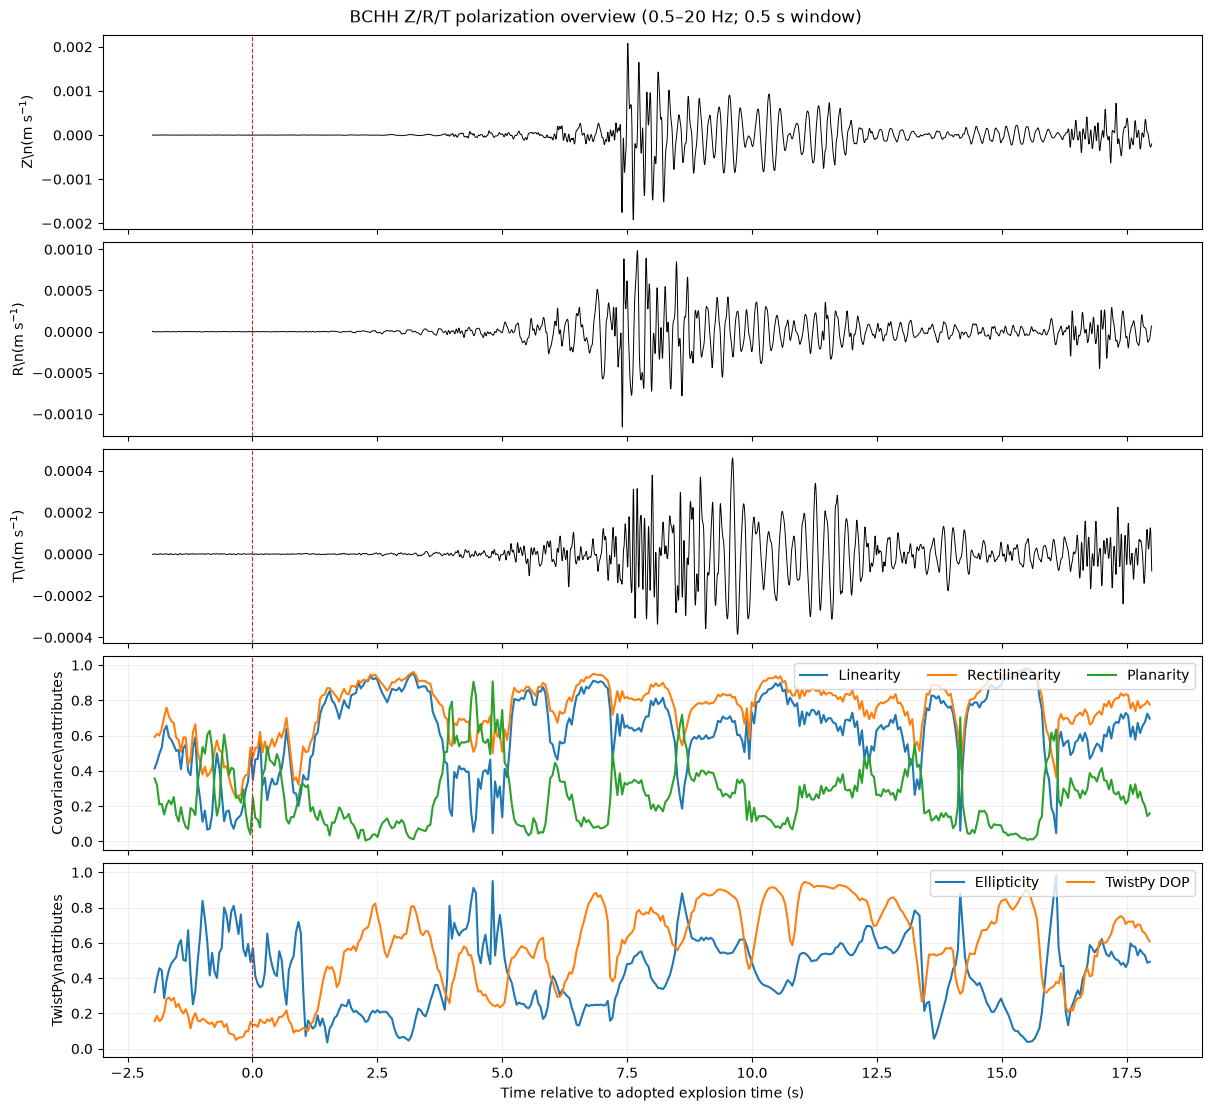

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_polarization_diagnostics.png
BCHH TwistPy polarization — geographic Z/N/E: plotting 416 polarization windows from 2016-09-01T13:07:10.080000Z to 2016-09-01T13:07:30.080000Z


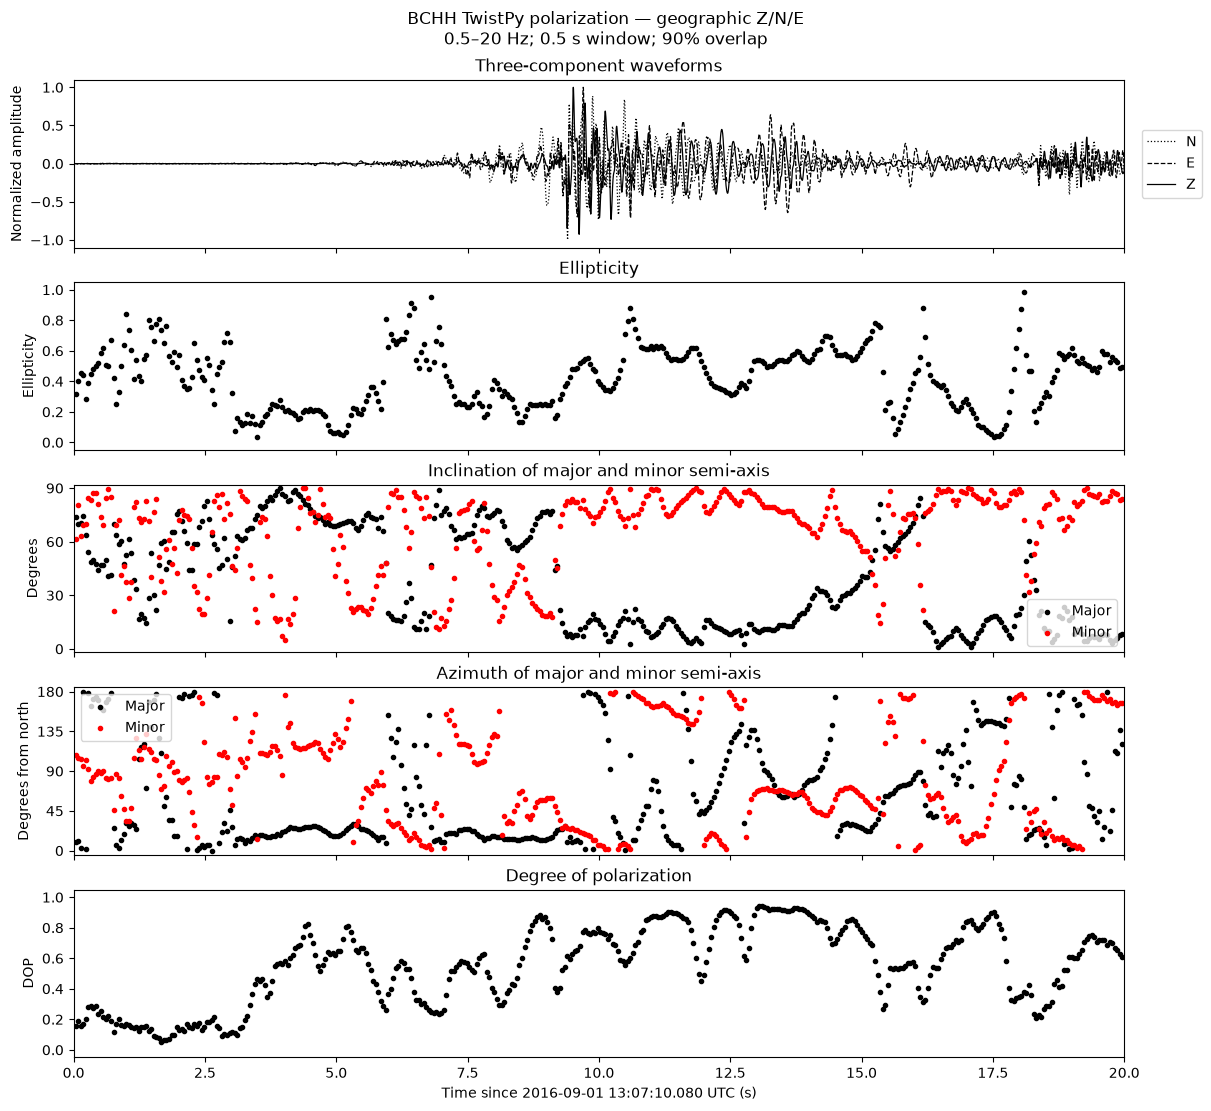

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_style_zne.png
BCHH TwistPy polarization — source-relative Z/R/T: plotting 416 polarization windows from 2016-09-01T13:07:10.080000Z to 2016-09-01T13:07:30.080000Z


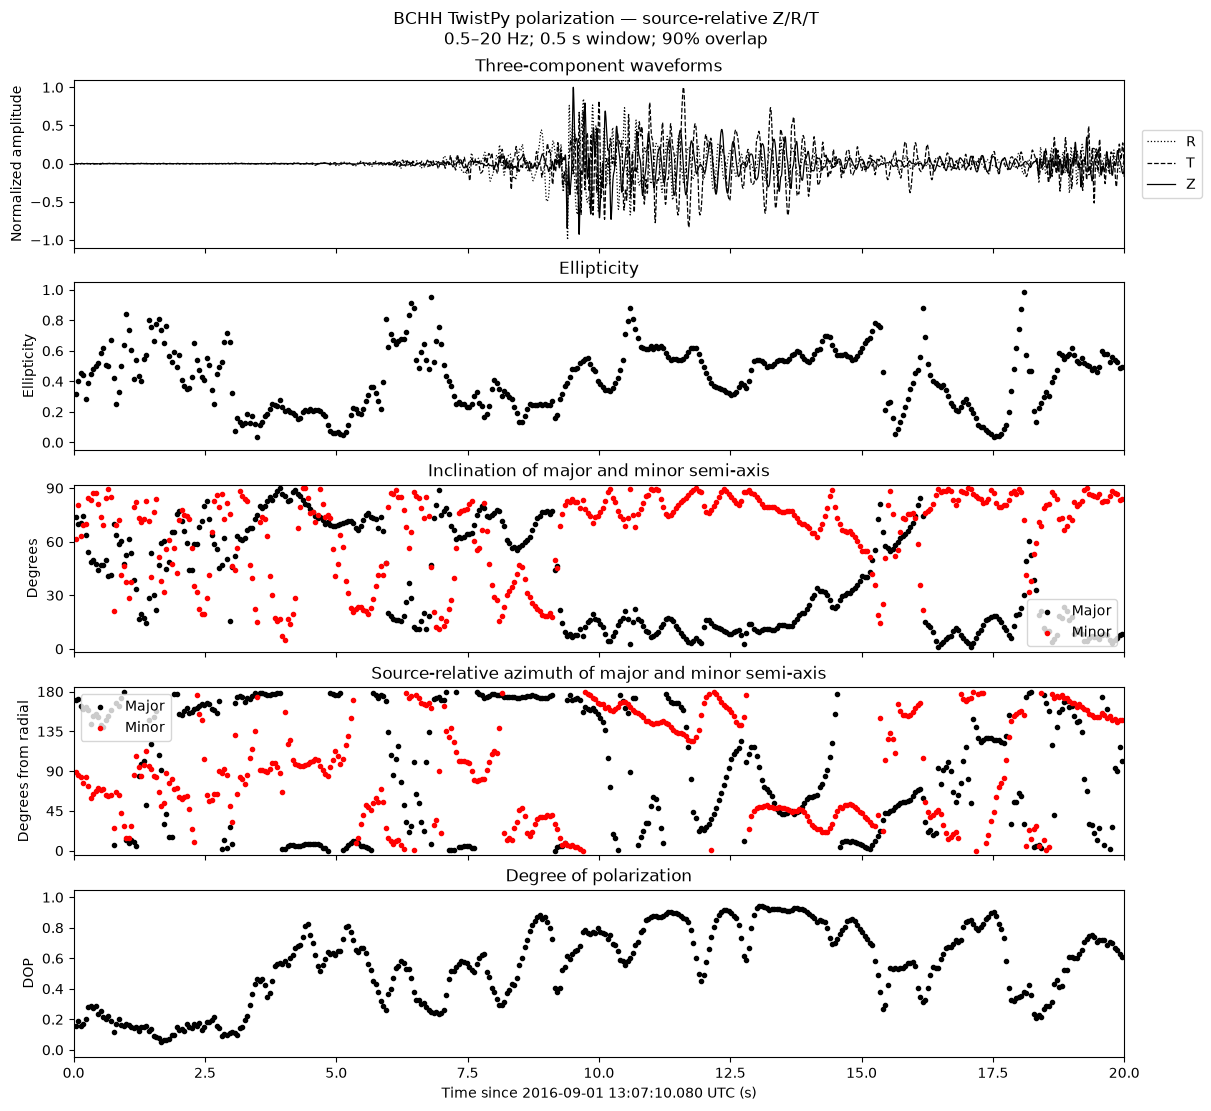

Saved: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/figures2/12_twistpy_style_zrt.png


In [8]:
def normalized_data(trace: Trace) -> np.ndarray:
    """Normalize a trace by its largest absolute finite value."""
    values = np.asarray(trace.data, dtype=float)
    finite = np.isfinite(values)
    if not finite.any():
        return values
    scale = np.nanmax(np.abs(values[finite]))
    if not NORMALIZE_COMPONENTS or not np.isfinite(scale) or scale == 0.0:
        return values
    return values / scale


def subset_polarization(starttime: UTCDateTime, endtime: UTCDateTime) -> pd.DataFrame:
    start_epoch = utc_epoch_seconds(starttime)
    end_epoch = utc_epoch_seconds(endtime)
    out = polarization.loc[
        (polarization["time_epoch_s"] >= start_epoch)
        & (polarization["time_epoch_s"] <= end_epoch)
    ].copy()
    if out.empty:
        available_start = polarization["time_epoch_s"].min()
        available_end = polarization["time_epoch_s"].max()
        raise ValueError(
            "No polarization windows overlap the requested plot interval.\n"
            f"Requested: {starttime} to {endtime}\n"
            f"Available: {UTCDateTime(available_start)} to "
            f"{UTCDateTime(available_end)}\n"
            "This usually indicates an incorrect conversion of TwistPy's "
            "time axis."
        )

    out["plot_time_s"] = out["time_epoch_s"] - start_epoch
    if not SHOW_LOW_DOP or DOP_DISPLAY_THRESHOLD > 0.0:
        low_dop = out["degree_of_polarization"] < DOP_DISPLAY_THRESHOLD
        orientation_columns = [
            "twistpy_major_azimuth_deg",
            "twistpy_minor_azimuth_deg",
            "twistpy_major_source_relative_azimuth_deg",
            "twistpy_minor_source_relative_azimuth_deg",
            "twistpy_major_inclination_deg",
            "twistpy_minor_inclination_deg",
        ]
        out.loc[low_dop, orientation_columns] = np.nan
    return out


def plot_twistpy_style(
    stream: Stream,
    components: tuple[str, str, str],
    labels: tuple[str, str, str],
    starttime: UTCDateTime,
    endtime: UTCDateTime,
    *,
    azimuth_mode: str,
    output_path: Path,
    title: str,
) -> None:
    """Create a five-panel figure modeled on the TwistPy example figure."""
    plot_stream = stream.copy().trim(starttime, endtime, pad=False)
    plot_pol = subset_polarization(starttime, endtime)
    print(
        f"{title}: plotting {len(plot_pol)} polarization windows "
        f"from {starttime} to {endtime}"
    )

    if azimuth_mode == "geographic":
        major_az_col = "twistpy_major_azimuth_deg"
        minor_az_col = "twistpy_minor_azimuth_deg"
        az_title = "Azimuth of major and minor semi-axis"
        az_ylabel = "Degrees from north"
    elif azimuth_mode == "source_relative":
        major_az_col = "twistpy_major_source_relative_azimuth_deg"
        minor_az_col = "twistpy_minor_source_relative_azimuth_deg"
        az_title = "Source-relative azimuth of major and minor semi-axis"
        az_ylabel = "Degrees from radial"
    else:
        raise ValueError(f"Unsupported azimuth_mode: {azimuth_mode}")

    fig, axes = plt.subplots(
        5, 1, figsize=(12, 11), sharex=True,
        gridspec_kw={"height_ratios": [1.0, 1.0, 1.0, 1.0, 1.0]},
        constrained_layout=True,
    )

    # Top panel: all three components, normalized as in the supplied example.
    line_styles = (":", "--", "-")
    for component, label, linestyle in zip(components, labels, line_styles):
        trace = unique_component(plot_stream, component)
        time_s = trace.times(reftime=starttime)
        axes[0].plot(
            time_s,
            normalized_data(trace),
            linestyle=linestyle,
            color="black",
            lw=WAVEFORM_LINEWIDTH,
            label=label,
        )
    axes[0].set_ylabel("Normalized amplitude" if NORMALIZE_COMPONENTS else "Amplitude")
    axes[0].legend(loc="center left", bbox_to_anchor=(1.01, 0.5))
    axes[0].set_title("Three-component waveforms")

    # TwistPy-style scatter panels.
    axes[1].scatter(
        plot_pol["plot_time_s"], plot_pol["ellipticity"],
        s=POLARIZATION_MARKER_SIZE, c="black",
    )
    axes[1].set_ylim(-0.05, 1.05)
    axes[1].set_ylabel("Ellipticity")
    axes[1].set_title("Ellipticity")

    axes[2].scatter(
        plot_pol["plot_time_s"], plot_pol["twistpy_major_inclination_deg"],
        s=POLARIZATION_MARKER_SIZE, c="black", label="Major",
    )
    axes[2].scatter(
        plot_pol["plot_time_s"], plot_pol["twistpy_minor_inclination_deg"],
        s=POLARIZATION_MARKER_SIZE, c="red", label="Minor",
    )
    axes[2].set_ylim(-2, 92)
    axes[2].set_yticks([0, 30, 60, 90])
    axes[2].set_ylabel("Degrees")
    axes[2].set_title("Inclination of major and minor semi-axis")
    axes[2].legend(loc="lower right")

    axes[3].scatter(
        plot_pol["plot_time_s"], plot_pol[major_az_col],
        s=POLARIZATION_MARKER_SIZE, c="black", label="Major",
    )
    axes[3].scatter(
        plot_pol["plot_time_s"], plot_pol[minor_az_col],
        s=POLARIZATION_MARKER_SIZE, c="red", label="Minor",
    )
    axes[3].set_ylim(-5, 185)
    axes[3].set_yticks([0, 45, 90, 135, 180])
    axes[3].set_ylabel(az_ylabel)
    axes[3].set_title(az_title)
    axes[3].legend(loc="upper left")

    axes[4].scatter(
        plot_pol["plot_time_s"], plot_pol["degree_of_polarization"],
        s=POLARIZATION_MARKER_SIZE, c="black",
    )
    axes[4].set_ylim(-0.05, 1.05)
    axes[4].set_ylabel("DOP")
    axes[4].set_title("Degree of polarization")
    axes[4].set_xlabel(
        f"Time since {starttime.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3]} UTC (s)"
    )

    for ax in axes:
        ax.set_xlim(0.0, float(endtime - starttime))
        ax.grid(False)

    fig.suptitle(
        f"{title}\n"
        f"{FILTER_FREQMIN_HZ:g}–{FILTER_FREQMAX_HZ:g} Hz; "
        f"{WINDOW_LENGTH_S:g} s window; {WINDOW_OVERLAP:.0%} overlap"
    )
    fig.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)


# Compact overview retained for rapid QC.
plot_stream = st_analysis_zrt.copy().trim(PLOT_START, PLOT_END, pad=False)
plot_pol = subset_polarization(PLOT_START, PLOT_END)
plot_pol["elapsed_from_explosion_s"] = (
    plot_pol["time_epoch_s"] - utc_epoch_seconds(config.EXPLOSION_TIME)
)

fig, axes = plt.subplots(5, 1, figsize=(12, 11), sharex=True, constrained_layout=True)
for ax, component in zip(axes[:3], ("Z", "R", "T")):
    trace = unique_component(plot_stream, component)
    times_s = trace.times(reftime=config.EXPLOSION_TIME)
    ax.plot(times_s, trace.data, color="black", lw=0.7)
    ax.set_ylabel(f"{component}\\n(m s$^{{-1}}$)")
    ax.axvline(0.0, color="tab:red", lw=0.8, ls="--")

axes[3].plot(plot_pol["elapsed_from_explosion_s"], plot_pol["linearity"], label="Linearity")
axes[3].plot(plot_pol["elapsed_from_explosion_s"], plot_pol["rectilinearity"], label="Rectilinearity")
axes[3].plot(plot_pol["elapsed_from_explosion_s"], plot_pol["planarity"], label="Planarity")
axes[3].set_ylim(-0.05, 1.05)
axes[3].set_ylabel("Covariance\\nattributes")
axes[3].legend(loc="upper right", ncol=3)

axes[4].plot(plot_pol["elapsed_from_explosion_s"], plot_pol["ellipticity"], label="Ellipticity")
axes[4].plot(plot_pol["elapsed_from_explosion_s"], plot_pol["degree_of_polarization"], label="TwistPy DOP")
axes[4].set_ylim(-0.05, 1.05)
axes[4].set_ylabel("TwistPy\\nattributes")
axes[4].set_xlabel("Time relative to adopted explosion time (s)")
axes[4].legend(loc="upper right", ncol=2)
for ax in axes[3:]:
    ax.axvline(0.0, color="tab:red", lw=0.8, ls="--")
    ax.grid(True, alpha=0.2)
fig.suptitle(
    f"BCHH Z/R/T polarization overview ({FILTER_FREQMIN_HZ:g}–{FILTER_FREQMAX_HZ:g} Hz; "
    f"{WINDOW_LENGTH_S:g} s window)"
)
fig.savefig(DIAGNOSTIC_FIGURE, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", DIAGNOSTIC_FIGURE)

# Figure matching the supplied TwistPy example in geographic coordinates.
plot_twistpy_style(
    st_analysis_zne,
    components=("N", "E", "Z"),
    labels=("N", "E", "Z"),
    starttime=PLOT_START,
    endtime=PLOT_END,
    azimuth_mode="geographic",
    output_path=TWISTPY_ZNE_FIGURE,
    title="BCHH TwistPy polarization — geographic Z/N/E",
)

# Source-relative version: waveform panel is truly Z/R/T, and ellipse azimuth
# is measured relative to the SLC-40 radial direction.
plot_twistpy_style(
    st_analysis_zrt,
    components=("R", "T", "Z"),
    labels=("R", "T", "Z"),
    starttime=PLOT_START,
    endtime=PLOT_END,
    azimuth_mode="source_relative",
    output_path=TWISTPY_ZRT_FIGURE,
    title="BCHH TwistPy polarization — source-relative Z/R/T",
)


## 9. Authoritative outputs


In [9]:
authoritative_outputs = {
    "polarization CSV": POLARIZATION_CSV,
    "polarization NPZ": POLARIZATION_NPZ,
    "rotated ZNE Stream": ROTATED_ZNE_PICKLE,
    "rotated ZRT Stream": ROTATED_ZRT_PICKLE,
    "processing summary": SUMMARY_JSON,
    "compact diagnostic figure": DIAGNOSTIC_FIGURE,
    "TwistPy-style ZNE figure": TWISTPY_ZNE_FIGURE,
    "TwistPy-style ZRT figure": TWISTPY_ZRT_FIGURE,
}
for label, path in authoritative_outputs.items():
    if not Path(path).exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    print(f"{label}: {path}")


polarization CSV: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.csv
polarization NPZ: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_polarization_timeseries.npz
rotated ZNE Stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zne.pkl
rotated ZRT Stream: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outputs2/12_polarization/12_seismic_zrt.pkl
processing summary: /Users/thompsong/Library/CloudStorage/Box-Box/thompsong/3_Project_Documents/NASAprojects/201602_Rocket_Seismology/writing/spacex_paper/data/outp